In [1]:
#数据处理模块，以及依赖库导入
%run data_process.ipynb
from feature_extractor.features_extractor import Data_features_extractor

import tensorflow as tf
import time
from net.base_cnn import *
from net.triplet import triplet_net,triplet_loss
from tensorflow.keras import optimizers


from sklearn import datasets       #导入数据模块
from sklearn.model_selection import train_test_split     #导入切分训练集、测试集模块
from sklearn.neighbors import KNeighborsClassifier

from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np


D:\anaconda\lib\site-packages\pkg_resources\__init__.py:122: PkgResourcesDeprecationWarning: py is an invalid version and will not be supported in a future release
  warnings.warn(


# 该部分代码主要用于第一阶段与第二阶段的高维特征对比实验

In [2]:
# #数据预处理内容，仅需处理一次

# #对原音频进行长度整合切分
# clip_audio()

# #训练集降噪，测试集降噪，结果集降噪
# reduce_noise()
# reduce_noise_for_test()

In [3]:
#按照顺序，不打乱的提取去一定格式的训练和验证数据
#获取三类训练数据
#获取三类验证数据

# BASE_MODE = "mfcc-base"
# DELTA_MODE = "mfcc-delta"
# DELTA_DELTA_MODE = "mfcc-delta-delta"
# RASTA_MODE = "raste"
# PLP_MODE = "plp"
# RASTA_PLP_MODE = "raste-plp"
# MFCC_RASTA_MODE = "mfcc-raste"

train_datas=Data_features_extractor('train',"plp",All=False).get_data()
val_datas=Data_features_extractor('test',"plp",All=False).get_data()



AD File AD_F_030807_001.wav audio file result: 473280/473280
(97, 13)
Extracted file: AD_F_030807_001.wav
AD File AD_F_040006_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040006_001.wav
AD File AD_F_040006_002.wav audio file result: 787360/787360
(97, 13)
Extracted file: AD_F_040006_002.wav
AD File AD_F_040108_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_001.wav
AD File AD_F_040108_002.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_002.wav
AD File AD_F_040108_003.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_003.wav
AD File AD_F_040108_004.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_004.wav
AD File AD_F_040108_005.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_005.wav
AD File AD_F_040108_006.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_F_040108_006.wav
AD File AD_F_040108_007.wav audio file result:

Extracted file: AD_M_230706_001.wav
AD File AD_M_242608_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: AD_M_242608_001.wav
HC File HC_F_019202_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_001.wav
HC File HC_F_019202_002.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_002.wav
HC File HC_F_019202_003.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_003.wav
HC File HC_F_019202_004.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_004.wav
HC File HC_F_019202_005.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_005.wav
HC File HC_F_019202_006.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019202_006.wav
HC File HC_F_019204_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019204_001.wav
HC File HC_F_019204_002.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_F_019204_002.wav
HC File HC

Extracted file: HC_M_019203_005.wav
HC File HC_M_019205_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019205_001.wav
HC File HC_M_019205_002.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019205_002.wav
HC File HC_M_019205_003.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019205_003.wav
HC File HC_M_019205_004.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019205_004.wav
HC File HC_M_019205_005.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019205_005.wav
HC File HC_M_019205_006.wav audio file result: 534720/534720
(97, 13)
Extracted file: HC_M_019205_006.wav
HC File HC_M_019209_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019209_001.wav
HC File HC_M_019209_002.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019209_002.wav
HC File HC_M_019209_003.wav audio file result: 959840/959840
(97, 13)
Extracted file: HC_M_019209_003.wav
HC File HC

Extracted file: MCI_F_250426_001.wav
MCI File MCI_F_251008_001.wav audio file result: 447040/447040
(97, 13)
Extracted file: MCI_F_251008_001.wav
MCI File MCI_F_252310_001.wav audio file result: 488160/488160
(97, 13)
Extracted file: MCI_F_252310_001.wav
MCI File MCI_M_022512_001.wav audio file result: 832800/832800
(97, 13)
Extracted file: MCI_M_022512_001.wav
MCI File MCI_M_030708_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: MCI_M_030708_001.wav
MCI File MCI_M_030708_002.wav audio file result: 592000/592000
(97, 13)
Extracted file: MCI_M_030708_002.wav
MCI File MCI_M_031918_001.wav audio file result: 630400/630400
(97, 13)
Extracted file: MCI_M_031918_001.wav
MCI File MCI_M_032613_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: MCI_M_032613_001.wav
MCI File MCI_M_040385_001.wav audio file result: 634880/634880
(97, 13)
Extracted file: MCI_M_040385_001.wav
MCI File MCI_M_042308_001.wav audio file result: 959840/959840
(97, 13)
Extracted file: MCI

C:\Users\dell\Desktop\re_triplet_model_2s_2dCNN_HC_MCI_90%\feature_extractor\features_extractor.py:219: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(self.datas)


Extracted file: 0002.wav
AD File 0005.wav audio file result: 872320/872320
(97, 13)
Extracted file: 0005.wav
AD File 0009.wav audio file result: 875040/875040
(97, 13)
Extracted file: 0009.wav
AD File 0011.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0011.wav
AD File 0012.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0012.wav
AD File 0013.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0013.wav
AD File 0015.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0015.wav
AD File 0017.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0017.wav
AD File 0020.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0020.wav
AD File 0025.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0025.wav
AD File 0027.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0027.wav
AD File 0030.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0030.wav
AD File 0037.wav audio file result: 959840/959840
(

Extracted file: 0068.wav
MCI File 0070.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0070.wav
MCI File 0071.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0071.wav
MCI File 0072.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0072.wav
MCI File 0073.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0073.wav
MCI File 0076.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0076.wav
MCI File 0077.wav audio file result: 829280/829280
(97, 13)
Extracted file: 0077.wav
MCI File 0080.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0080.wav
MCI File 0083.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0083.wav
MCI File 0090.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0090.wav
MCI File 0091.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0091.wav
MCI File 0100.wav audio file result: 959840/959840
(97, 13)
Extracted file: 0100.wav
MCI File 0103.wav audio file result: 959

In [4]:
for data in train_datas:
    print(np.array(data).shape)
for data in val_datas:
    print(np.array(data).shape)

(4177, 97, 13)
(5649, 97, 13)
(4732, 97, 13)
(2005, 97, 13)
(2542, 97, 13)
(2214, 97, 13)


In [5]:
#分别生成用于模型1与模型2的训练和验证数据
train_d_one=[[],[]]
val_d_one=[[],[]]

train_d_two=[[],[]]
val_d_two=[[],[]]


#train与val datas中  0为AD 1为HC 2为MCI

#train_d_one中，0为AD 1为HC与MCI
train_d_one[0]=np.array(train_datas[0])

#----------------------------------------
# np.random.shuffle(train_datas[1])
# np.random.shuffle(train_datas[2])


# temp_one=np.concatenate((train_datas[1][:train_d_one[0].shape[0]//2],train_datas[2][:train_d_one[0].shape[0]//2]),axis=0)
# np.random.shuffle(temp_one)
# train_d_one[1]=temp_one
#----------------------------------------


train_d_one[1]=(np.concatenate((train_datas[1],train_datas[2]),axis=0))
np.random.shuffle(train_d_one[1])


Len=train_d_one[1].shape[0]-train_d_one[0].shape[0]
arr_index = np.random.randint(0, train_d_one[0].shape[0], (Len, )) 
train_d_one[0]=(np.concatenate((train_d_one[0],train_d_one[0][arr_index]),axis=0))
np.random.shuffle(train_d_one[0])

#val_d_one中，0为AD 1为HC与MCI
val_d_one[0]=np.array(val_datas[0])


#---------------------------------------------
# np.random.shuffle(val_datas[1])
# np.random.shuffle(val_datas[2])

# temp_two=np.concatenate((val_datas[1][:val_d_one[0].shape[0]//2],val_datas[2][:val_d_one[0].shape[0]//2]),axis=0)
# np.random.shuffle(temp_two)

# val_d_one[1]=temp_two
#----------------------------------------


val_d_one[1]=(np.concatenate((val_datas[1],val_datas[2]),axis=0))
np.random.shuffle(val_d_one[1])

Len=val_d_one[1].shape[0]-val_d_one[0].shape[0]
arr_index = np.random.randint(0, val_d_one[0].shape[0], (Len, )) 
val_d_one[0]=(np.concatenate((val_d_one[0],val_d_one[0][arr_index]),axis=0))
np.random.shuffle(val_d_one[0])


print("this is the train datas for one")
print("AD:",train_d_one[0].shape,' ',"HC,MCI:",train_d_one[1].shape)
print("this is the val datas for one")
print("AD:",val_d_one[0].shape,' ',"HC,MCI:",val_d_one[1].shape)
print("=============================================================================")


#train_d_two中，0为HC 1为MCI
train_d_two[0]=np.array(train_datas[1])
train_d_two[1]=np.array(train_datas[2])

#val_d_two中，0为HC 1为MCI
val_d_two[0]=np.array(val_datas[1])
val_d_two[1]=np.array(val_datas[2])

print("this is the train datas for two")
print("HC:",train_d_two[0].shape,' ',"MCI:",train_d_two[1].shape)
print("this is the val datas for two")
print("HC:",val_d_two[0].shape,' ',"MCI:",val_d_two[1].shape)
print("=============================================================================")

train_d_one=np.array(train_d_one)
val_d_one=np.array(val_d_one)

train_d_two=np.array(train_d_two)
val_d_two=np.array(val_d_two)


this is the train datas for one
AD: (10381, 97, 13)   HC,MCI: (10381, 97, 13)
this is the val datas for one
AD: (4756, 97, 13)   HC,MCI: (4756, 97, 13)
this is the train datas for two
HC: (5649, 97, 13)   MCI: (4732, 97, 13)
this is the val datas for two
HC: (2542, 97, 13)   MCI: (2214, 97, 13)


C:\Users\dell\AppData\Local\Temp\ipykernel_8328\1433330627.py:82: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  train_d_two=np.array(train_d_two)
C:\Users\dell\AppData\Local\Temp\ipykernel_8328\1433330627.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  val_d_two=np.array(val_d_two)


In [6]:
#当前已经获取到训练集以及验证集数据。

#train_d_one=[[],[]]
#val_d_one=[[],[]]

#train_d_two=[[],[]]
#val_d_two=[[],[]]

# def make_triplet_test(datas,BATCH_SIZE):
#     triplet_datas=[]
#     for i  in range(2):#因一共两类
#         Len=datas[i].shape[0]
#         for j in range(Len):#遍历当前类
#             for k in range(1):#随机样本选取个数
#                 #选取anchor
#                 anchor=datas[i][j]
            
#                 #选择positive_1
#                 positive_1 = datas[i][random.randrange(0, Len)]
            
            
#                 #选择negative_1
#                 inc = random.randrange(1, 2)#选取一个1到2（不包含2）的随机整数
#                 dn1 = (i + inc) % 2#取得新的类别的下标
#                 Len_dn1=datas[dn1].shape[0]
#                 negative_1 = datas[dn1][random.randrange(0,Len_dn1)]#选从随机取得的类中，随机选一个样本
            
            
#                 triplet_datas+=[[anchor,positive_1,negative_1]]
            
#     #数据对已经创建完毕,将其转换为numpy，方便重新排序。
#     triplet_datas=np.array(triplet_datas)
#     '''
#     np.random.shuffle(triplet_datas)
#     triplet_datas=triplet_datas[:(int)(triplet_datas.shape[0]*(1/2))]
#     '''
#     print(triplet_datas.shape[0])
    
#     triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,32000,1) #将音频格式转为适合卷积的标准形式，增加一个维度，表示一个通道。
    
#     labels = np.empty((triplet_datas.shape[0],))
    
#     datas = tf.data.Dataset.from_tensor_slices((triplet_datas, labels))
    
#     datas=datas.shuffle(labels.shape[0]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
   
   
#     return datas




In [7]:
#构造数据生成器
#generator
#需要产生格式为(batch_size,3,297,39,1) 标签格式为(batch_size,)


#如何计算一个周期能生成多少批数据？
#((datas[0].shape[0]+datas[1].shape[0])*times)//batch_size


def triplet_generator(datas, batch_size, times=1,reshuffle_each_iteration=False):
# all_image_paths: 所有图片的路径列表
# all_mask_paths: 所有标签的路径列表
# batch_size: 批大小
# reshuffle_each_iteration: 每个epoch结束后是否打乱数据
    i = 0
    counts=0
    triplet_datas=[]
    while True:    
        for i  in range(2):#因一共两类,用于anchor类别的互换
            Len=datas[i].shape[0]
            for j in range(Len):#遍历当前类
                for k in range(times):#随机样本选取个数
                    #选取anchor
                    anchor=datas[i][j]
                    #print(np.array(anchor).shape)
                    #选择positive_1
                    positive_1 = datas[i][random.randrange(0, Len)]


                    #选择negative_1
                    inc = random.randrange(1, 2)#选取一个1到2（不包含2）的随机整数
                    dn1 = (i + inc) % 2#取得新的类别的下标
                    Len_dn1=datas[dn1].shape[0]
                    negative_1 = datas[dn1][random.randrange(0,Len_dn1)]#选从随机取得的类中，随机选一个样本
                    triplet_datas+=[[anchor,positive_1,negative_1]]
                    counts+=1
                    if counts==batch_size:
                        triplet_datas=np.array(triplet_datas)
                        #triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,297,39,1) 6s
                        triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,97,26,1)
                        labels = np.empty((triplet_datas.shape[0],))
                        yield triplet_datas, labels
                        triplet_datas=[]
                        counts=0
                        
                        
        
def triplet_generator_v2(datas, batch_size ,reshuffle_each_iteration=True):
# batch_size: 批大小
# reshuffle_each_iteration: 每个epoch结束后是否打乱数据
    
    #批计数器
    counts=0
    
    #批Triplet组
    triplet_datas=[]
    
    #类长
    len_0=datas[0].shape[0]
    len_1=datas[1].shape[0]
    
    
    #不同类别下标，与当前下标
    index_0=-1
    index_1=-1
    curindex=0
    
    while True:        
        classnum=random.randint(0,1)#随机挑选类别
        
        #确定当前index
        if classnum==0:
            index_0+=1
            curindex=index_0
        else:
            index_1+=1
            curindex=index_1
            
        #不满足条件时，更换类别
        if classnum==0 and index_0>=len_0:
            classnum=1
            index_1+=1
            curindex=index_1
            
        if classnum==1 and index_1>=len_1:
            classnum=0
            index_0+=1
            curindex=index_0
        
        #一周期后打乱数据。
        if index_0>=len_0 and index_1>=len_1:
            index_0=-1
            index_1=-1
            if reshuffle_each_iteration:
                np.random.shuffle(datas[0])
                np.random.shuffle(datas[1])
            continue
            
            
        anchor=datas[classnum][curindex]
            
        #选择positive
        positive_1 = datas[classnum][random.randrange(0,datas[classnum].shape[0])]
            
        #选择negative
        dn1 = (classnum + 1) % 2#取得新的类别的下标            
        negative_1 = datas[dn1][random.randrange(0,datas[dn1].shape[0])]#选从随机取得的类中，随机选一个样本
            
        triplet_datas+=[[anchor,positive_1,negative_1]]
        counts+=1
        
        if counts==batch_size:
            triplet_datas=np.array(triplet_datas)
            triplet_datas=np.expand_dims(triplet_datas, axis=-1)
            labels = np.empty((triplet_datas.shape[0],))
            yield triplet_datas, labels
            triplet_datas=[]
            counts=0        


# 第一阶段

# 2dcnn

In [8]:
#65
#39
Bc_one=Base_cnn([97,39,1])
#构建triplet model one
model_one=triplet_net([3,97,39,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_one.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 64),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//64,
    validation_data=triplet_generator_v2(val_d_one, 64),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//64)
    Bc_one.save('save_model/model_one/'+str(i))

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 36s 83ms/step - loss: 1.7997 - val_loss: 1.7995
INFO:tensorflow:Assets written to: save_model/model_one/0\assets
  2/324 [..............................] - ETA: 25s - loss: 1.8102

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 30s 91ms/step - loss: 1.8000 - val_loss: 1.7996
INFO:tensorflow:Assets written to: save_model/model_one/1\assets
  1/324 [..............................] - ETA: 31s - loss: 1.8135

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


...

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 33s 103ms/step - loss: 0.7807 - val_loss: 1.6707
INFO:tensorflow:Assets written to: save_model/model_one/83\assets
  1/324 [..............................] - ETA: 28s - loss: 0.7472

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


 82/324 [======>.......................] - ETA: 22s - loss: 0.7900

KeyboardInterrupt: 

# 2D CNN+attention

In [17]:
#65
#39
Bc_one=Base_cnn_ec([97,13,1])
#构建triplet model one
model_one=triplet_net([3,97,13,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_one.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 64),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//64,
    validation_data=triplet_generator_v2(val_d_one, 64),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//64)
    Bc_one.save('save_model/model_one/'+str(i))

324/324 [==============================] - 11s 31ms/step - loss: 1.8001 - val_loss: 1.7998
INFO:tensorflow:Assets written to: save_model/model_one/0\assets
  3/324 [..............................] - ETA: 8s - loss: 1.8041 

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 10s 31ms/step - loss: 1.8001 - val_loss: 1.7997
INFO:tensorflow:Assets written to: save_model/model_one/1\assets
  1/324 [..............................] - ETA: 10s - loss: 1.7979

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 10s 31ms/step - loss: 1.7999 - val_loss: 1.7997
INFO:tensorflow:Assets written to: save_model/model_one/2\assets
  1/324 [..............................] - ETA: 10s - loss: 1.8001

...

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


324/324 [==============================] - 10s 32ms/step - loss: 0.9725 - val_loss: 1.6203
INFO:tensorflow:Assets written to: save_model/model_one/55\assets
  1/324 [..............................] - ETA: 10s - loss: 1.0542

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


 87/324 [=======>......................] - ETA: 6s - loss: 0.9826

KeyboardInterrupt: 

# 第二阶段

# 2d cnn

In [8]:
Bc_two=Base_cnn([97,13,1])
Bc_two.summary()


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 97, 13, 1)]       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 97, 13, 64)        640       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 97, 13, 64)        36928     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 48, 6, 64)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 48, 6, 128)        73856     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 48, 6, 128)        147584    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 24, 3, 128)        0     

In [ ]:
#6s重叠4s，取得效果最优

#构建triplet model two
model_two=triplet_net([3,97,13,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(200):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 16),
    steps_per_epoch=(train_d_two[0].shape[0]+train_d_two[1].shape[0])//16,
    validation_data=triplet_generator_v2(val_d_two, 16),
    validation_steps=(val_d_two[0].shape[0]+val_d_two[1].shape[0])//16)
    #if i+1>=50:
    Bc_two.save('save_model/model_two/'+str(i))

In [87]:
for i in range(100):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 16),
    steps_per_epoch=(train_d_two[0].shape[0]+train_d_two[1].shape[0])//16,
    validation_data=triplet_generator_v2(val_d_two, 16),
    validation_steps=(val_d_two[0].shape[0]+val_d_two[1].shape[0])//16)
    #if i+1>=50:
    Bc_two.save('save_model/model_two/'+str(i))

  2/648 [..............................] - ETA: 49s - loss: 0.7510 

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 9s 14ms/step - loss: 0.6979 - val_loss: 0.8922
INFO:tensorflow:Assets written to: save_model/model_two/0\assets
 13/648 [..............................] - ETA: 8s - loss: 0.6837

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 10s 15ms/step - loss: 0.6814 - val_loss: 0.8987
INFO:tensorflow:Assets written to: save_model/model_two/1\assets
 13/648 [..............................] - ETA: 8s - loss: 0.6389

...

648/648 [==============================] - 9s 14ms/step - loss: 0.4345 - val_loss: 0.8417
INFO:tensorflow:Assets written to: save_model/model_two/97\assets
  9/648 [..............................] - ETA: 8s - loss: 0.5474

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 9s 14ms/step - loss: 0.4299 - val_loss: 0.8018
INFO:tensorflow:Assets written to: save_model/model_two/98\assets
 14/648 [..............................] - ETA: 7s - loss: 0.5148

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 9s 14ms/step - loss: 0.4262 - val_loss: 0.7705
INFO:tensorflow:Assets written to: save_model/model_two/99\assets


# 2d cnn+attention

In [10]:
Bc_two=Base_cnn_ec([97,13,1])
Bc_two.summary()


Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 97, 13, 1)]  0                                            
__________________________________________________________________________________________________
conv2d_4 (Conv2D)               (None, 97, 13, 64)   640         input_3[0][0]                    
__________________________________________________________________________________________________
conv2d_5 (Conv2D)               (None, 97, 13, 64)   36928       conv2d_4[0][0]                   
__________________________________________________________________________________________________
max_pooling2d_3 (MaxPooling2D)  (None, 48, 6, 64)    0           conv2d_5[0][0]                   
____________________________________________________________________________________________

In [ ]:
#构建triplet model two
model_two=triplet_net([3,97,13,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(150):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 16),
    steps_per_epoch=(train_d_two[0].shape[0]+train_d_two[1].shape[0])//16,
    validation_data=triplet_generator_v2(val_d_two, 16),
    validation_steps=(val_d_two[0].shape[0]+val_d_two[1].shape[0])//16)
    #if i+1>=50:
    Bc_two.save('save_model/model_two/'+str(i))

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 15s 15ms/step - loss: 1.7978 - val_loss: 1.7989
INFO:tensorflow:Assets written to: save_model/model_two/0\assets
  5/648 [..............................] - ETA: 8s - loss: 1.7910 

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 9s 14ms/step - loss: 1.7891 - val_loss: 1.7936
INFO:tensorflow:Assets written to: save_model/model_two/1\assets
  5/648 [..............................] - ETA: 8s - loss: 1.7823 

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


...

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 9s 14ms/step - loss: 0.6104 - val_loss: 0.9035
INFO:tensorflow:Assets written to: save_model/model_two/116\assets
  1/648 [..............................] - ETA: 11s - loss: 0.6578

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '
D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


648/648 [==============================] - 12s 18ms/step - loss: 0.6267 - val_loss: 0.9111


D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


# 查看分类结果

# step one

In [10]:
#获取用于knn的测试集与验证集

#model_29最高 84.57

#26和36
Bc_one=tf.keras.models.load_model('save_model/model_one/70')
t_d_one,t_l_one = make_new_datas_knn(train_d_one,Bc_one)
v_d_one,v_l_one = make_new_datas_knn(val_d_one,Bc_one)
    

(4224, 16)
(4224,)


D:\anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


val_datas_one


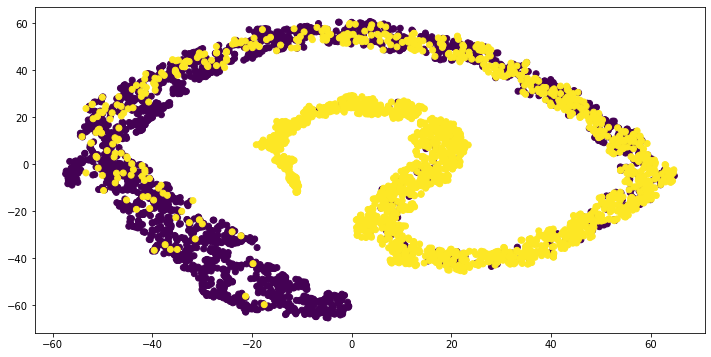

In [7]:
#展示Bc_two效果
#train_datas_T_one,train_labels_T_one = make_new_datas_tsne(train_d_one,Bc_one)
val_datas_T_one,val_labels_T_one = make_new_datas_tsne(val_d_one,Bc_one)

#---------------------------------------------------------------------------------

# print(train_datas_T_two.shape)
# print(train_labels_T_two.shape)
# # 使用TSNE进行降维处理。降至2维。
# tsne =TSNE(n_components=2, learning_rate=100).fit_transform(train_datas_T_two)
 
# print("train_datas_one")
# # 设置画布的大小
# plt.figure(figsize=(12, 6))
# plt.subplot(111)
# plt.scatter(tsne[:, 0], tsne[:, 1], c=train_labels_T_two)
# plt.show()




print(val_datas_T_one.shape)
print(val_labels_T_one.shape)
tsne = TSNE(n_components=2, learning_rate=100).fit_transform(val_datas_T_one)

# 设置画布的大小
plt.figure(figsize=(12, 6))
plt.subplot(111)
plt.scatter(tsne[:, 0], tsne[:, 1], c=val_labels_T_one)
plt.show()

In [11]:
from xgboost import XGBClassifier
knn=XGBClassifier(learning_rate=0.01,n_estimators=500,max_depth=9,min_child_weight=0.8,gamma=1,subsample=0.5,  
                         colsample_bytree=0.9,objective= 'binary:logistic',scale_pos_weight=1,seed=100,reg_alpha=0.001)
#knn = KNeighborsClassifier(n_neighbors=300)    #实例化KNN模型
knn.fit(t_d_one, t_l_one)      #放入训练数据进行训练
pred=knn.predict(v_d_one) 

D:\anaconda\lib\site-packages\xgboost\compat.py:31: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
D:\anaconda\lib\site-packages\pkg_resources\__init__.py:122: PkgResourcesDeprecationWarning: py is an invalid version and will not be supported in a future release
  warnings.warn(
D:\anaconda\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[10:21:48] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [7]:
 #获得平均的单个段的识别率
Len=v_l_one.shape[0]
num=0
for i in range(Len):
    if(pred[i]==v_l_one[i]):
        num+=1
Accuracy=num/Len
print("Accuracy:",Accuracy)

NameError: name 'v_l_one' is not defined

In [13]:
Data_for_one=get_datas_for_test_NOW("plp",'test',Bc_one,All=False)

ValueError: Input 0 is incompatible with layer model: expected shape=(None, 97, 39, 1), found shape=(1, 97, 13)

In [ ]:
#0为HC 1为MCI

ad=0
n_ad=0
#三类音频
for p in range(3):
    print(p)
    for m in range(len(Data_for_one[p])):#j指类中的数组对
        Audio=Data_for_one[p][m]

        pred=knn.predict(Audio)#pred为预测的标签
        a=0
        b=0        
        #计算预测的的结果
        #0为ad 1为hc_mci
        for k in pred:
            if(k==0):
                a+=1
            if(k==1):
                b+=1

        res=b/(a+b)   
        if(res<=0.8and p==0):#认定为HC
            ad+=1
        if(res>0.8 and p!=0):#否则认定为MCI,进而进行第二次分类
            n_ad+=1

#ad准确率
print("ad:",ad/np.array(Data_for_one[0]).shape[0])

#n_ad准确率
print("n_ad:",n_ad/(np.array(Data_for_one[1]).shape[0]+np.array(Data_for_one[2]).shape[0]))

print("average:",(ad/np.array(Data_for_one[0]).shape[0]+n_ad/(np.array(Data_for_one[1]).shape[0]+np.array(Data_for_one[2]).shape[0]))/2)

# step two

In [8]:
#获取用于knn的测试集与验证集

#model_29最高 84.57

#26和36
Bc_two=tf.keras.models.load_model('save_model/model_two/99')
t_d_two,t_l_two = make_new_datas_knn(train_d_two,Bc_two)
v_d_two,v_l_two = make_new_datas_knn(val_d_two,Bc_two)

(4756, 32)
(4756,)


D:\anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


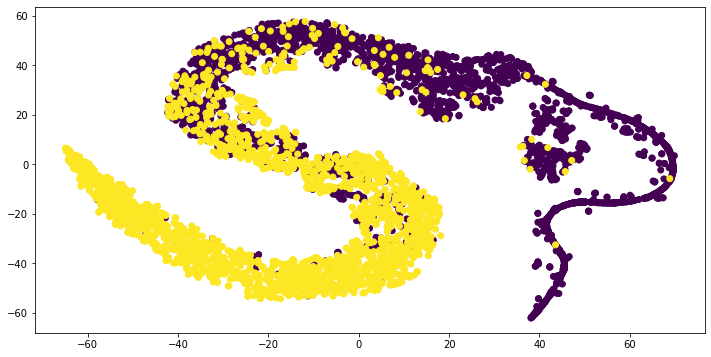

In [89]:
#展示Bc_two效果
#train_datas_T_two,train_labels_T_two = make_new_datas_tsne(train_d_two,Bc_two)
val_datas_T_two,val_labels_T_two = make_new_datas_tsne(val_d_two,Bc_two)

#---------------------------------------------------------------------------------

# print(train_datas_T_two.shape)
# print(train_labels_T_two.shape)
# # 使用TSNE进行降维处理。降至2维。
# tsne =TSNE(n_components=2, learning_rate=100).fit_transform(train_datas_T_two)
 
# print("train_datas_one")
# # 设置画布的大小
# plt.figure(figsize=(12, 6))
# plt.subplot(111)
# plt.scatter(tsne[:, 0], tsne[:, 1], c=train_labels_T_two)
# plt.show()




print(val_datas_T_two.shape)
print(val_labels_T_two.shape)
tsne = TSNE(n_components=2, learning_rate=100).fit_transform(val_datas_T_two)


# 设置画布的大小
plt.figure(figsize=(12, 6))
plt.subplot(111)
plt.scatter(tsne[:, 0], tsne[:, 1], c=val_labels_T_two)
plt.show()

In [9]:
from xgboost import XGBClassifier
xgb=XGBClassifier(learning_rate=0.001,n_estimators=300,max_depth=8,min_child_weight=0.8,gamma=1,subsample=0.8,  
                         colsample_bytree=0.9,objective= 'binary:logistic',scale_pos_weight=1,seed=100,reg_alpha=0.001)
#knn = KNeighborsClassifier(n_neighbors=300)    #实例化KNN模型
xgb.fit(t_d_two, t_l_two)      #放入训练数据进行训练
pred=xgb.predict(v_d_two) 

D:\anaconda\lib\site-packages\xgboost\compat.py:31: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
D:\anaconda\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[18:12:06] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [1]:
 #获得平均的单个段的识别率
Len=v_l_two.shape[0]
num=0
for i in range(Len):
    if(pred[i]==v_l_two[i]):
        num+=1
Accuracy=num/Len
print("Accuracy:",Accuracy)

NameError: name 'v_l_two' is not defined

In [18]:
import joblib
#lr是一个LogisticRegression模型
joblib.dump(xgb, 'step_two.model')
#lr = joblib.load('lr.model')

['step_two.model']

In [11]:
Data_for_two=get_datas_for_test_NOW("plp",'test',Bc_two,All=False,method='feature')

In [17]:
hc=0
mci=0
#三类音频
for p in [1,2]:
    for m in range(len(Data_for_two[p])):#j指类中的数组对
        Audio=Data_for_two[p][m]

        pred=xgb.predict(Audio)#pred为预测的标签
        a=0
        b=0        
        #计算预测的的结果
        #0为hc 1为mci
        for k in pred:
            if(k==0):
                a+=1
            if(k==1):
                b+=1

        res=b/(a+b)   
        if(res<=0.4 and p==1):#认定为hc
            hc+=1
        if(res>0.4 and p!=1):#否则认定为mci,进而进行第二次分类
            mci+=1

#hc准确率
print("hc:",hc/np.array(Data_for_two[1]).shape[0])

#mci准确率
print("mci:",mci/np.array(Data_for_two[2]).shape[0])

print("average:",(hc/np.array(Data_for_two[1]).shape[0]+mci/(np.array(Data_for_two[2]).shape[0]))/2)

hc: 0.8888888888888888
mci: 0.9487179487179487
average: 0.9188034188034188


C:\Users\dell\AppData\Local\Temp\ipykernel_8328\916599777.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("hc:",hc/np.array(Data_for_two[1]).shape[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_8328\916599777.py:29: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("mci:",mci/np.array(Data_for_two[2]).shape[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_8328\916599777.py:31: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) 

In [33]:
train_d_two[0].shape

(7598, 72, 39)

In [77]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,input_shape=(16,), activation='relu'),
    tf.keras.layers.Dense(2,activation='sigmoid')
])

In [78]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [85]:
model.fit(t_d_two,t_l_two, epochs=1000, batch_size=512,validation_data=(v_d_two,v_l_two))

Epoch 1/1000
28/28 [==============================] - 0s 3ms/step - loss: 0.5263 - accuracy: 0.7293 - val_loss: 0.5601 - val_accuracy: 0.7001
Epoch 2/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5258 - accuracy: 0.7300 - val_loss: 0.5617 - val_accuracy: 0.6984
Epoch 3/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5255 - accuracy: 0.7295 - val_loss: 0.5604 - val_accuracy: 0.6973
Epoch 4/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5251 - accuracy: 0.7308 - val_loss: 0.5621 - val_accuracy: 0.6987
Epoch 5/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5267 - accuracy: 0.7279 - val_loss: 0.5596 - val_accuracy: 0.7010
Epoch 6/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5257 - accuracy: 0.7288 - val_loss: 0.5607 - val_accuracy: 0.6973
Epoch 7/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5251 - accuracy: 0.7284 - val_loss: 0.5599 - val_accuracy: 0.6979
Epoch 

28/28 [==============================] - 0s 2ms/step - loss: 0.5124 - accuracy: 0.7381 - val_loss: 0.5497 - val_accuracy: 0.7059
Epoch 116/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5135 - accuracy: 0.7376 - val_loss: 0.5494 - val_accuracy: 0.7062
Epoch 117/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5130 - accuracy: 0.7370 - val_loss: 0.5521 - val_accuracy: 0.7063
Epoch 118/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5119 - accuracy: 0.7407 - val_loss: 0.5523 - val_accuracy: 0.7037
Epoch 119/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5120 - accuracy: 0.7376 - val_loss: 0.5524 - val_accuracy: 0.7054
Epoch 120/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5113 - accuracy: 0.7376 - val_loss: 0.5506 - val_accuracy: 0.7020
Epoch 121/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5113 - accuracy: 0.7398 - val_loss: 0.5498 - val_accuracy: 0.7037
Epoch 1

Epoch 172/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5089 - accuracy: 0.7378 - val_loss: 0.5528 - val_accuracy: 0.7076
Epoch 173/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5083 - accuracy: 0.7411 - val_loss: 0.5508 - val_accuracy: 0.6962
Epoch 174/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5082 - accuracy: 0.7411 - val_loss: 0.5527 - val_accuracy: 0.7001
Epoch 175/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5083 - accuracy: 0.7416 - val_loss: 0.5511 - val_accuracy: 0.6985
Epoch 176/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5079 - accuracy: 0.7411 - val_loss: 0.5496 - val_accuracy: 0.7060
Epoch 177/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5073 - accuracy: 0.7429 - val_loss: 0.5532 - val_accuracy: 0.7068
Epoch 178/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5081 - accuracy: 0.7406 - val_loss: 0.5516 - val_accuracy:

Epoch 229/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5063 - accuracy: 0.7424 - val_loss: 0.5518 - val_accuracy: 0.7074
Epoch 230/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5054 - accuracy: 0.7434 - val_loss: 0.5499 - val_accuracy: 0.6987
Epoch 231/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5058 - accuracy: 0.7416 - val_loss: 0.5499 - val_accuracy: 0.7009
Epoch 232/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5061 - accuracy: 0.7416 - val_loss: 0.5509 - val_accuracy: 0.6949
Epoch 233/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5063 - accuracy: 0.7424 - val_loss: 0.5513 - val_accuracy: 0.6985
Epoch 234/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5055 - accuracy: 0.7431 - val_loss: 0.5522 - val_accuracy: 0.7024
Epoch 235/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5061 - accuracy: 0.7412 - val_loss: 0.5501 - val_accuracy:

Epoch 286/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5040 - accuracy: 0.7428 - val_loss: 0.5521 - val_accuracy: 0.6965
Epoch 287/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5043 - accuracy: 0.7447 - val_loss: 0.5509 - val_accuracy: 0.6946
Epoch 288/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5043 - accuracy: 0.7436 - val_loss: 0.5508 - val_accuracy: 0.6976
Epoch 289/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5035 - accuracy: 0.7457 - val_loss: 0.5508 - val_accuracy: 0.6971
Epoch 290/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5053 - accuracy: 0.7433 - val_loss: 0.5528 - val_accuracy: 0.7004
Epoch 291/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5041 - accuracy: 0.7414 - val_loss: 0.5517 - val_accuracy: 0.6979
Epoch 292/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.5042 - accuracy: 0.7443 - val_loss: 0.5517 - val_accuracy:

...

Epoch 742/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4971 - accuracy: 0.7477 - val_loss: 0.5557 - val_accuracy: 0.6999
Epoch 743/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4968 - accuracy: 0.7481 - val_loss: 0.5536 - val_accuracy: 0.7005
Epoch 744/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4961 - accuracy: 0.7498 - val_loss: 0.5512 - val_accuracy: 0.7030
Epoch 745/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4967 - accuracy: 0.7479 - val_loss: 0.5528 - val_accuracy: 0.6966
Epoch 746/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4968 - accuracy: 0.7494 - val_loss: 0.5578 - val_accuracy: 0.7002
Epoch 747/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4963 - accuracy: 0.7512 - val_loss: 0.5545 - val_accuracy: 0.7032
Epoch 748/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4965 - accuracy: 0.7477 - val_loss: 0.5531 - val_accuracy:

Epoch 799/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4957 - accuracy: 0.7472 - val_loss: 0.5537 - val_accuracy: 0.7041
Epoch 800/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4957 - accuracy: 0.7502 - val_loss: 0.5522 - val_accuracy: 0.6995
Epoch 801/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4950 - accuracy: 0.7499 - val_loss: 0.5538 - val_accuracy: 0.6929
Epoch 802/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4957 - accuracy: 0.7494 - val_loss: 0.5553 - val_accuracy: 0.6915
Epoch 803/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4956 - accuracy: 0.7472 - val_loss: 0.5522 - val_accuracy: 0.7030
Epoch 804/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4951 - accuracy: 0.7489 - val_loss: 0.5560 - val_accuracy: 0.7002
Epoch 805/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4954 - accuracy: 0.7487 - val_loss: 0.5531 - val_accuracy:

Epoch 856/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4944 - accuracy: 0.7470 - val_loss: 0.5540 - val_accuracy: 0.6963
Epoch 857/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4956 - accuracy: 0.7501 - val_loss: 0.5563 - val_accuracy: 0.6987
Epoch 858/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4948 - accuracy: 0.7497 - val_loss: 0.5545 - val_accuracy: 0.6995
Epoch 859/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4952 - accuracy: 0.7488 - val_loss: 0.5518 - val_accuracy: 0.7004
Epoch 860/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4953 - accuracy: 0.7491 - val_loss: 0.5554 - val_accuracy: 0.6999
Epoch 861/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4945 - accuracy: 0.7493 - val_loss: 0.5595 - val_accuracy: 0.6993
Epoch 862/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4960 - accuracy: 0.7479 - val_loss: 0.5564 - val_accuracy:

Epoch 913/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4951 - accuracy: 0.7487 - val_loss: 0.5555 - val_accuracy: 0.6944
Epoch 914/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4938 - accuracy: 0.7503 - val_loss: 0.5536 - val_accuracy: 0.7059
Epoch 915/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4945 - accuracy: 0.7487 - val_loss: 0.5525 - val_accuracy: 0.7030
Epoch 916/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4952 - accuracy: 0.7499 - val_loss: 0.5535 - val_accuracy: 0.6946
Epoch 917/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4933 - accuracy: 0.7498 - val_loss: 0.5533 - val_accuracy: 0.7004
Epoch 918/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4942 - accuracy: 0.7503 - val_loss: 0.5526 - val_accuracy: 0.7024
Epoch 919/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4948 - accuracy: 0.7487 - val_loss: 0.5544 - val_accuracy:

Epoch 970/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4938 - accuracy: 0.7508 - val_loss: 0.5546 - val_accuracy: 0.7063
Epoch 971/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4944 - accuracy: 0.7494 - val_loss: 0.5534 - val_accuracy: 0.7001
Epoch 972/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4935 - accuracy: 0.7496 - val_loss: 0.5555 - val_accuracy: 0.6973
Epoch 973/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4938 - accuracy: 0.7510 - val_loss: 0.5561 - val_accuracy: 0.6960
Epoch 974/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4938 - accuracy: 0.7486 - val_loss: 0.5535 - val_accuracy: 0.6955
Epoch 975/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4941 - accuracy: 0.7488 - val_loss: 0.5566 - val_accuracy: 0.7030
Epoch 976/1000
28/28 [==============================] - 0s 2ms/step - loss: 0.4938 - accuracy: 0.7486 - val_loss: 0.5560 - val_accuracy:

In [126]:
train_datas[0][0][0]

array([ 8.04248470e+00, -6.82766996e-01, -7.04115920e-01, -4.97767855e-01,
        8.13429537e-02, -3.71812063e-01, -4.12558017e-01, -2.00353343e-01,
       -6.08500485e-01, -5.40746386e-01, -5.23034417e-01, -1.83765332e-01,
       -1.78765967e-01, -9.48898636e-02,  2.64091315e-02,  7.39804775e-02,
        2.09933667e-02, -1.09988402e-01,  4.80658247e-02,  2.17721496e-02,
       -7.95415559e-02,  5.79559965e-02,  1.61152518e-01,  3.82008591e-02,
        3.74671128e-02, -1.09855366e-02,  1.07285581e-01,  2.25411603e-02,
        1.16230560e-02,  2.32944565e-02,  1.37570555e-02, -1.34148415e-02,
       -5.10236115e-02,  2.87219040e-02,  4.37751255e-02, -3.43382397e-02,
       -1.99104805e-02, -7.53616787e-03,  1.53214930e-02])